# **TRAINING CONVOLUTIONAL NEURAL NETWORKS** 

## First Version

## Import Libraries

In [12]:
import numpy as np
import tensorflow as tf
import pandas as pd
import numpy as np

## **Import data** 

In [13]:
import numpy as np
import tensorflow as tf

tf.random.set_seed(1234)
path_train = "Train"
path_test = "Test"
# Training sample
train = tf.keras.preprocessing.image_dataset_from_directory(
    path_train, image_size=(250, 250), shuffle=True, label_mode="binary"
)
# Validation sample
test = tf.keras.preprocessing.image_dataset_from_directory(
    path_test, image_size=(250, 250), shuffle=True, label_mode="binary"
)
classes = train.class_names
X_train, y_train = np.array([]).reshape(-1, 250, 250, 3), np.array([]).reshape(-1, 1)
for X, y in train:
    X_train = np.concatenate([X_train, X])
    y_train = np.concatenate([y_train, y])

Found 1281 files belonging to 2 classes.
Found 363 files belonging to 2 classes.


2026-03-07 22:22:20.442086: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## **2. BUILDING THE NETWORK'S ARCHITECTURE**

In [19]:
import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    # --- STEP 1: INPUT & DATA AUGMENTATION ---
    layers.RandomFlip("horizontal", input_shape=(250, 250, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Rescaling(1.0 / 255),

    # --- THE CONVOLUTIONAL BASE ---
    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(2),

    # --- THE CLASSIFICATION HEAD (Crucial for fixing the error) ---
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5, seed=1234),

    # This final layer makes the output shape (None, 1) to match your target
    layers.Dense(1, activation="sigmoid") 
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 250, 250, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 250, 250, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 248, 248, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 59, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    27,558,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,582,497 (105.22 MB)

 Trainable params: 27,582,497 (105.22 MB)

 Non-trainable params: 0 (0.00 B)

## **3. TRAINING THE MODEL**

In [20]:
# 1. Update the Checkpoint to the modern .keras format
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "model.keras", 
    monitor="val_accuracy", 
    save_best_only=True, 
    mode="auto"
)

# 2. ADD THIS: Early Stopping safety switch
# This stops training if val_loss doesn't improve for 3 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 3. Keep your class weights as they are
class_weight = {0: 1 / np.mean(y_train), 1: 1.0}

# 4. Updated Fit call with the new callback
model.compile(loss="binary_crossentropy", optimizer="RMSprop", metrics=["accuracy"])

model.fit(
    train,
    epochs=20, # You can increase epochs now because EarlyStopping will protect you
    validation_data=test,
    verbose=1,
    callbacks=[checkpoint, early_stop], # Added early_stop here
    class_weight=class_weight,
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 889ms/step - accuracy: 0.6425 - loss: 3.2516 - val_accuracy: 0.5592 - val_loss: 0.6871
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 36s 875ms/step - accuracy: 0.6550 - loss: 1.0733 - val_accuracy: 0.5592 - val_loss: 0.6871
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 915ms/step - accuracy: 0.6550 - loss: 1.0627 - val_accuracy: 0.5592 - val_loss: 0.7091
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 926ms/step - accuracy: 0.6550 - loss: 1.0032 - val_accuracy: 0.5592 - val_loss: 0.7619


## **4. EVALUATING THE MODEL'S PERFORMANCE**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import classification_report

# 1. Load the modern .keras format
model = tf.keras.models.load_model("model.keras")

# 2. Direct evaluation
acc = model.evaluate(test)
print("Accuracy over validation: {:.2f}%".format(acc[1] * 100))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.5592 - loss: 0.6871
Accuracy over validation: 55.92%


2026-03-07 22:36:43.045252: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step
              precision    recall  f1-score   support

        Down       0.56      1.00      0.72       203
          Up       0.00      0.00      0.00       160

    accuracy                           0.56       363
   macro avg       0.28      0.50      0.36       363
weighted avg       0.31      0.56      0.40       363



/Users/mac/Desktop/work-project/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mac/Desktop/work-project/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mac/Desktop/work-project/venv311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

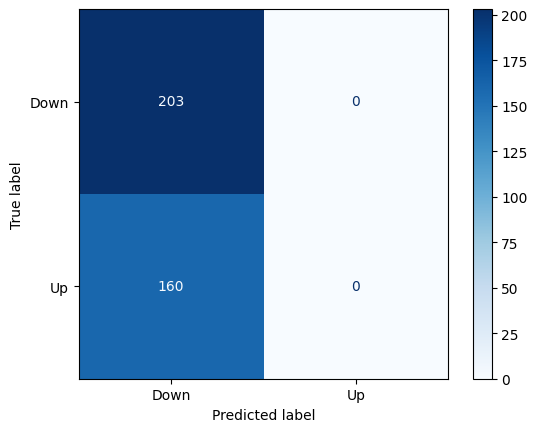

In [22]:

# 3. Efficient Prediction 
# Instead of manual loops, we extract labels and predict directly
y_test = np.concatenate([y for x, y in test], axis=0)
y_prob = model.predict(test) 
y_pred = np.round(y_prob)

# 4. Metrics & Confusion Matrix
print(classification_report(y_test, y_pred, target_names=classes))

cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(values_format="", cmap="Blues")
plt.show()

## Second Version

2026-03-08 14:18:05.417770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 1281 files belonging to 2 classes.
Found 363 files belonging to 2 classes.


2026-03-08 14:18:13.829319: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/mac/Desktop/work-project/venv311/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Calculated Class Weights: {0: 0.7634088200238379, 1: 1.4490950226244346}
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.4832 - loss: 2.0536 - val_accuracy: 0.4408 - val_loss: 1.8667
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5074 - loss: 1.2261 - val_accuracy: 0.4408 - val_loss: 3.3743
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4684 - loss: 1.1830 - val_accuracy: 0.4408 - val_loss: 4.1766
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5558 - loss: 1.1693 - val_accuracy: 0.4408 - val_loss: 4.0838
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5121 - loss: 1.1534 - val_accuracy: 0.4408 - val_loss: 3.0932
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5425 - loss: 1.1474 - val_accuracy: 0.4353 - val_loss: 1.6495
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4606 - loss: 1.1303 - val_accuracy: 0.4518 - val_loss: 1.1918
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/

2026-03-08 14:50:22.935742: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step

--- Final Classification Report ---
              precision    recall  f1-score   support

        Down       0.60      0.92      0.73       203
          Up       0.69      0.23      0.35       160

    accuracy                           0.61       363
   macro avg       0.64      0.57      0.54       363
weighted avg       0.64      0.61      0.56       363



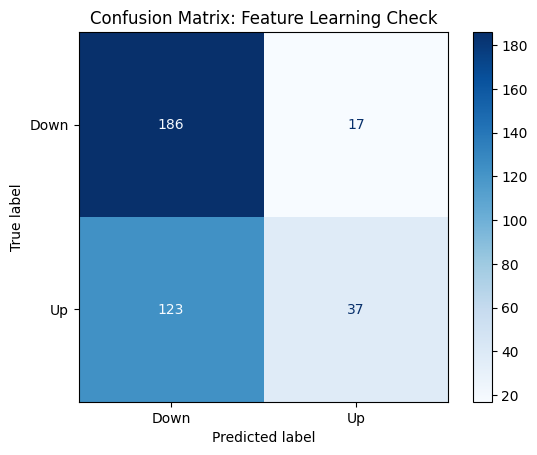

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn import metrics
from sklearn.metrics import classification_report

# --- 1. DATA CONFIGURATION & EFFICIENT LOADING ---
tf.random.set_seed(1234)
path_train = "Train"
path_test = "Test"
IMG_SIZE = (250, 250)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path_train, image_size=IMG_SIZE, shuffle=True, label_mode="binary", batch_size=32
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path_test, image_size=IMG_SIZE, shuffle=False, label_mode="binary", batch_size=32
)

classes = train_ds.class_names

# Compute class weights without loading all images into memory
y_train = np.concatenate([y for x, y in train_ds], axis=0)
neg, pos = np.bincount(y_train.flatten().astype(int))
total = neg + pos
class_weight = {0: (1 / neg) * (total / 2.0), 1: (1 / pos) * (total / 2.0)}
print(f"Calculated Class Weights: {class_weight}")

# --- 2. ARCHITECTURE DESIGN (QUANT-READY) ---
model = models.Sequential([
    # Data Augmentation (Step 1)
    layers.RandomFlip("horizontal", input_shape=(250, 250, 3)),
    layers.RandomRotation(0.05),
    layers.Rescaling(1.0 / 255),

    # Convolutional Base with BatchNormalization (Step 2)
    layers.Conv2D(16, 3, padding='same', activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(32, 3, padding='same', activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding='same', activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    # Classification Head with Regularization (Step 3)
    layers.Flatten(),
    layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5, seed=1234),
    layers.Dense(1, activation="sigmoid") 
])

# --- 3. TRAINING EXECUTION (Step 4) ---
# Switched to Adam for better convergence on imbalanced data
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint = callbacks.ModelCheckpoint(
    "model.keras", monitor="val_accuracy", save_best_only=True
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

model.fit(
    train_ds,
    epochs=30, # Increased because early_stop will handle the exit
    validation_data=test_ds,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weight
)

# --- 4. ADVANCED EVALUATION ---
model = models.load_model("model.keras")

# Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = (y_prob > 0.5).astype(int)

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = metrics.confusion_matrix(y_true, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Feature Learning Check")
plt.show()